>### key questions:
>>#### What are the average salaries for different experience levels?
>>#### How do salaries vary by job title and location?
>>#### What is the impact of remote work and company size on salaries?
>>#### Are there significant differences in salaries across regions?


>### Salaries by Experience Level

>>#### Entry-level (EN): Lower average salaries but significant regional variation.

>>#### Senior-level (SE): Highest salary growth compared to entry-level.

>>#### Executive-level (EX): Highest salaries with substantial variations across regions.

>### Job Titles and Salaries

>>#### Data Scientists and Engineers: Competitive but varied salaries.

>>#### Specialized Roles: Higher salaries for niche expertise (e.g., AI specialists).

>### Geographic Disparities

>>#### Salaries in North America outpace other regions.

>>#### Variations due to cost of living and industry concentration.

>>#### Impact of Remote Work and Company Size

>>#### Fully remote jobs showed competitive salaries across experience levels.

>>#### Larger companies tend to offer higher salaries compared to small and medium-sized enterprises (SMEs).

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from IPython.display import display

salary_data = pd.read_csv("global_tech_salary.txt")

display(salary_data.head())
display(salary_data.info())


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,MI,FT,Data Analyst,165000,USD,165000,AU,0,AU,M
1,2023,MI,FT,Data Analyst,70000,USD,70000,US,100,US,M
2,2024,MI,FT,Machine Learning Engineer,85000,EUR,94444,IE,100,IE,M
3,2024,SE,FT,Data Scientist,92700,USD,92700,US,0,US,M
4,2023,MI,FT,Research Engineer,150000,USD,150000,US,0,US,M


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           5000 non-null   int64 
 1   experience_level    5000 non-null   object
 2   employment_type     5000 non-null   object
 3   job_title           5000 non-null   object
 4   salary              5000 non-null   int64 
 5   salary_currency     5000 non-null   object
 6   salary_in_usd       5000 non-null   int64 
 7   employee_residence  5000 non-null   object
 8   remote_ratio        5000 non-null   int64 
 9   company_location    5000 non-null   object
 10  company_size        5000 non-null   object
dtypes: int64(4), object(7)
memory usage: 429.8+ KB


None

In [2]:
object_feature = salary_data.select_dtypes("object").columns

for feature in object_feature:
    print(salary_data[feature].value_counts())
    


experience_level
SE    3248
MI    1215
EN     375
EX     162
Name: count, dtype: int64
employment_type
FT    4975
CT      10
PT       9
FL       6
Name: count, dtype: int64
job_title
Data Engineer                             1067
Data Scientist                            1025
Data Analyst                               735
Machine Learning Engineer                  511
Research Scientist                         153
                                          ... 
Finance Data Analyst                         1
Encounter Data Management Professional       1
Big Data Developer                           1
Business Intelligence Lead                   1
Data Modeller                                1
Name: count, Length: 123, dtype: int64
salary_currency
USD    4623
GBP     171
EUR     151
CAD      20
INR      15
AUD       4
PLN       3
SGD       2
DKK       2
THB       2
PHP       1
NZD       1
MXN       1
JPY       1
CHF       1
BRL       1
TRY       1
Name: count, dtype: int64
employee_reside

In [3]:
print(salary_data["job_title"].unique())
salary_data[["job_title"]].value_counts().to_csv("job_title.csv", header=["job_title"])

['Data Analyst' 'Machine Learning Engineer' 'Data Scientist'
 'Research Engineer' 'Data Engineer'
 'Machine Learning Infrastructure Engineer' 'Analytics Engineer'
 'AI Research Engineer' 'Research Scientist' 'BI Analyst' 'ML Engineer'
 'Business Intelligence Analyst' 'AI Engineer' 'Research Analyst'
 'Staff Data Analyst' 'Data Infrastructure Engineer'
 'Data Operations Specialist' 'Machine Learning Scientist'
 'Applied Scientist' 'BI Developer' 'Machine Learning Researcher'
 'Data Science' 'Data Science Manager' 'Data Specialist' 'NLP Engineer'
 'Business Intelligence Engineer' 'Data Architect'
 'Data Science Practitioner' 'Computer Vision Engineer'
 'Data Science Lead' 'Insight Analyst' 'Data Manager' 'Decision Scientist'
 'Data Strategist' 'Data Integration Specialist' 'Data Product Manager'
 'Head of Data' 'Lead Data Analyst' 'Data Operations Associate'
 'Machine Learning Software Engineer' 'Data Analytics Manager'
 'Data Operations Analyst' 'Data Analytics Lead'
 'Business Intellig

### Data Cleaning 

In [1]:

employment_types = {
    "FT": "Full-Time",
    "CT": "Contract",
    "PT": "Part-Time",
    "FL": "Freelance"
}

experience_levels = {
    "SE": "Senior",
    "MI": "Mid-Level",
    "EN": "Entry-Level",
    "EX": "Executive"
}

country_codes = {
    "US": "United States",
    "GB": "United Kingdom",
    "CA": "Canada",
    "ES": "Spain",
    "DE": "Germany",
    "IN": "India",
    "FR": "France",
    "AU": "Australia",
    "PT": "Portugal",
    "BR": "Brazil",
    "NL": "Netherlands",
    "IE": "Ireland",
    "IT": "Italy",
    "PL": "Poland",
    "NG": "Nigeria",
    "EG": "Egypt",
    "AR": "Argentina",
    "CO": "Colombia",
    "VN": "Vietnam",
    "LT": "Lithuania",
    "ZA": "South Africa",
    "MX": "Mexico",
    "GR": "Greece",
    "SI": "Slovenia",
    "BE": "Belgium",
    "TR": "Turkey",
    "PH": "Philippines",
    "UA": "Ukraine",
    "EE": "Estonia",
    "JP": "Japan",
    "AE": "United Arab Emirates",
    "SG": "Singapore",
    "LV": "Latvia",
    "CF": "Central African Republic",
    "DK": "Denmark",
    "PK": "Pakistan",
    "GH": "Ghana",
    "MT": "Malta",
    "TH": "Thailand",
    "RO": "Romania",
    "HN": "Honduras",
    "AM": "Armenia",
    "CY": "Cyprus",
    "NZ": "New Zealand",
    "CH": "Switzerland",
    "RS": "Serbia",
    "RU": "Russia",
    "FI": "Finland",
    "HK": "Hong Kong",
    "SE": "Sweden",
    "EC": "Ecuador",
    "AT": "Austria",
    "KR": "South Korea",
    "MD": "Moldova",
    "IQ": "Iraq",
    "LU": "Luxembourg",
    "IL": "Israel",
    "MY": "Malaysia",
    "AS": "American Samoa"
}

remote_ratios = {
    0: "On-site",
    50: "Hybrid",
    100: "Fully Remote"
}

company_size = {
    "M": "Medium",
    "L": "Large",
    "S": "Small"
}

key_value = {
    "company_location" : country_codes,
    "employee_residence" : country_codes,
    "company_size":company_size,
    "employment_type":employment_types,
    "experience_level":experience_levels,
    "remote_ratio":remote_ratios
}


In [5]:
for key,value in key_value.items():
    salary_data[key] = salary_data[key].replace(value)
    

In [6]:
import re

patterns = {
    'Data Science & Engineering': [r'\bData\b.*\bEngineer\b', r'\bData Science\b', r'\bMachine Learning\b', 
                                   r'\bAI\b', r'\bApplied Scientist\b', r'\bData Science Engineer\b'],
    'Business Intelligence': [r'\bBusiness Intelligence\b', r'\bBI\b'],
    'Research & Development': [r'\bResearch\b', r'\bScientist\b'],
    'Data Analysis': [r'\bData Analyst\b', r'\bData Analytics\b'],
    'Management & Leadership': [r'\bManager\b', r'\bDirector\b'],
    'Specialized Roles': [r'\bNLP\b', r'\bComputer Vision\b', r'\bRobotics\b'],
    'Others': []
}

def categorize_title(title):
    for category, pattern in patterns.items():
        for p in pattern:
            if re.search(p, title, re.IGNORECASE):
                return category
    return "Other"  

salary_data['clustered_titles'] = salary_data['job_title'].apply(categorize_title)



In [7]:
print(salary_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           5000 non-null   int64 
 1   experience_level    5000 non-null   object
 2   employment_type     5000 non-null   object
 3   job_title           5000 non-null   object
 4   salary              5000 non-null   int64 
 5   salary_currency     5000 non-null   object
 6   salary_in_usd       5000 non-null   int64 
 7   employee_residence  5000 non-null   object
 8   remote_ratio        5000 non-null   object
 9   company_location    5000 non-null   object
 10  company_size        5000 non-null   object
 11  clustered_titles    5000 non-null   object
dtypes: int64(3), object(9)
memory usage: 468.9+ KB
None


In [8]:
object_feature = salary_data.select_dtypes("object").columns
salary_data[object_feature] = salary_data[object_feature].astype("category")
print(salary_data.info())
for feature in object_feature:
    print(salary_data[feature].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           5000 non-null   int64   
 1   experience_level    5000 non-null   category
 2   employment_type     5000 non-null   category
 3   job_title           5000 non-null   category
 4   salary              5000 non-null   int64   
 5   salary_currency     5000 non-null   category
 6   salary_in_usd       5000 non-null   int64   
 7   employee_residence  5000 non-null   category
 8   remote_ratio        5000 non-null   category
 9   company_location    5000 non-null   category
 10  company_size        5000 non-null   category
 11  clustered_titles    5000 non-null   category
dtypes: category(9), int64(3)
memory usage: 172.9 KB
None
experience_level
Senior         3248
Mid-Level      1215
Entry-Level     375
Executive       162
Name: count, dtype: int64
employment_t

In [9]:
print(salary_data[["work_year","salary_in_usd"]].describe())

         work_year  salary_in_usd
count  5000.000000    5000.000000
mean   2023.136400  148924.465200
std       0.696198   66986.391667
min    2020.000000   15000.000000
25%    2023.000000  100573.250000
50%    2023.000000  140304.000000
75%    2024.000000  185900.000000
max    2024.000000  750000.000000


### Exploratory Data Analysis (EDA)  

#### Univariate Analysis:

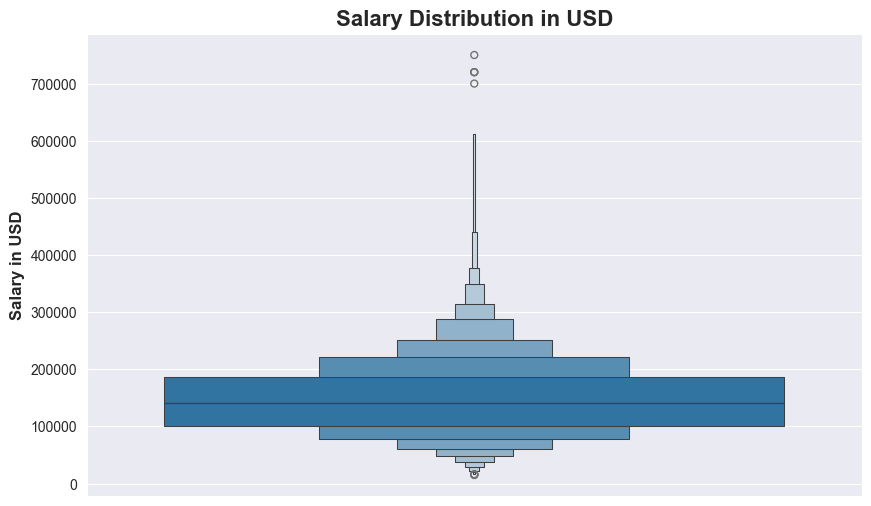

In [10]:
plt.figure(figsize=(10, 6))
sns.set_style("darkgrid")
salary_distribution = sns.boxenplot(data=salary_data, y="salary_in_usd")
salary_distribution.set_title("Salary Distribution in USD",
    fontsize=16,
    fontweight='bold')

salary_distribution.set_ylabel(
    "Salary in USD",
    fontsize=12,
    fontweight='bold'
)
salary_distribution.tick_params(axis='y', labelsize=10)
plt.show()

In [11]:
def count_plot(data, title):
    x = str(data.name).split('_',maxsplit=3)
    x_label = ""
    for word in x:
        x_label+=word
        x_label+=" "
    plt.figure(figsize=(8,6))
    plot = sns.countplot(x=data)
    plot.set_title(
        title,
        fontsize=16,
        fontweight='bold'
    )
    plot.set_xlabel(
        x_label,
        fontsize=12,
        fontweight='bold',
        rotation=45
    )
    plot.set_ylabel(
        "count",
        fontsize=12,
        fontweight='bold'
    )
    plot.tick_params(axis='x', rotation=45)
    plt.show()
    return plot

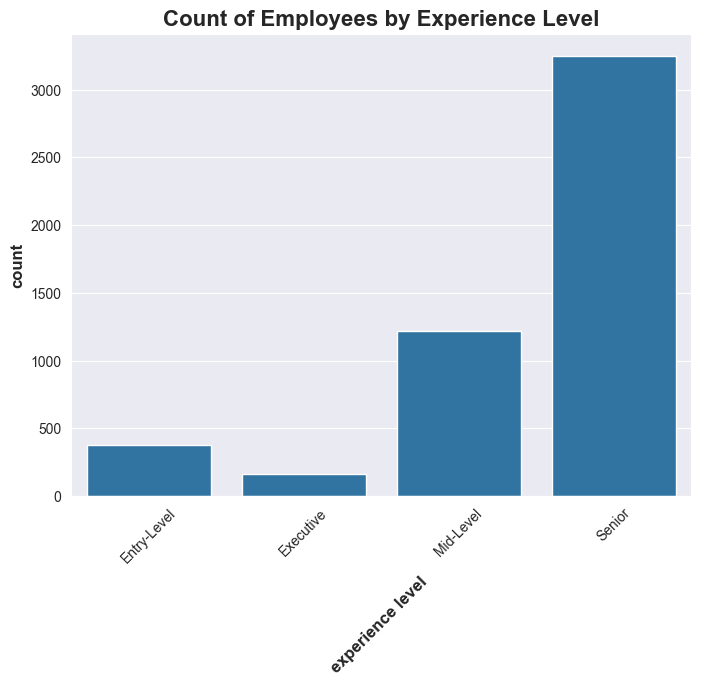

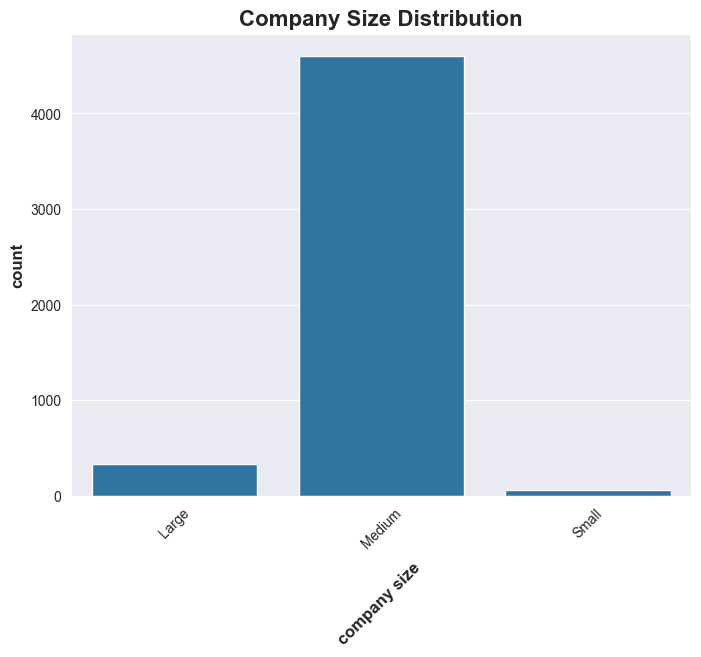

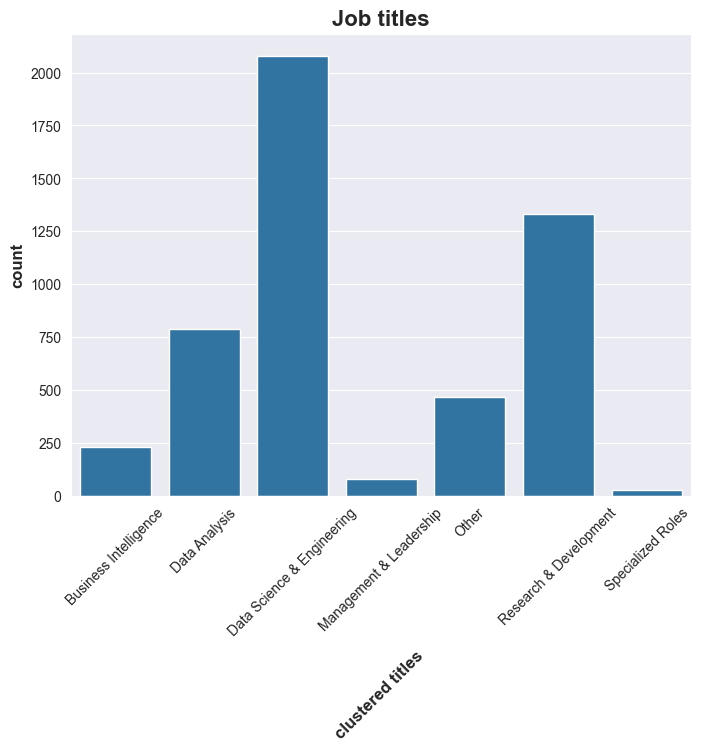

In [12]:
experience_levels_count = count_plot(salary_data["experience_level"], "Count of Employees by Experience Level")
company_size = count_plot(salary_data["company_size"], "Company Size Distribution")
clustered_titles = count_plot(salary_data["clustered_titles"], "Job titles")


#### Bivariate Analysis:

In [18]:
def salary_boxen_plot(hue):
    x = str(hue).split('_',maxsplit=3)
    x_label = ""
    for word in x:
        x_label+=word
        x_label+=" "    
    plt.figure(figsize=(10, 6))
    salary_distribution = sns.boxenplot(data=salary_data, y="salary_in_usd", hue=hue)
    salary_distribution.set_title("Salary Distribution in USD by "+x_label,
        fontsize=16,
        fontweight='bold')

    salary_distribution.set_ylabel(
        "Salary in USD",
        fontsize=12,
        fontweight='bold'
    )
    salary_distribution.tick_params(axis='y', labelsize=10)
    plt.show()
    return salary_distribution

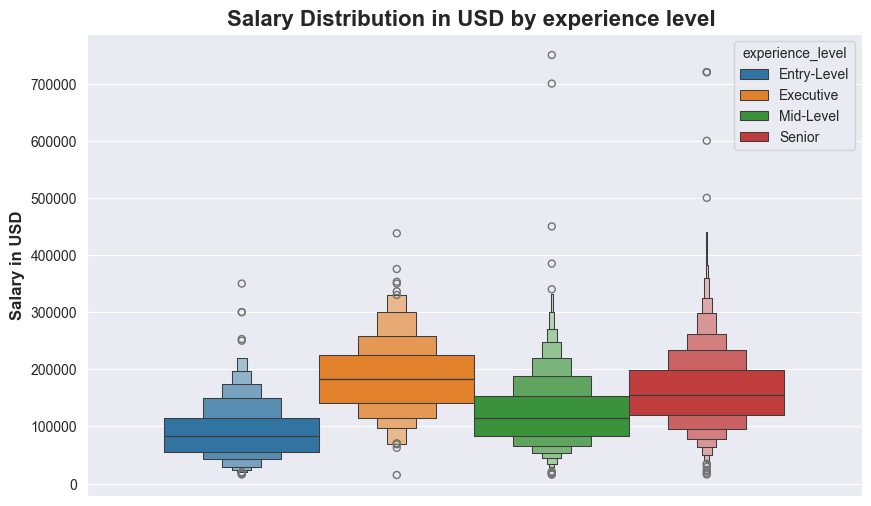

In [19]:
experience_level = salary_boxen_plot("experience_level")

C:\Users\nmn\AppData\Local\Temp\ipykernel_8412\3790277270.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_experience = salary_data.groupby("experience_level")["salary_in_usd"]\


  experience_level    min     max           mean
0      Entry-Level  16000  350000   90930.128000
1        Executive  15000  438000  188359.438272
2        Mid-Level  15680  750000  124433.395885
3           Senior  15809  720000  162814.877771


Text(0, 0.5, 'Salary in USD')

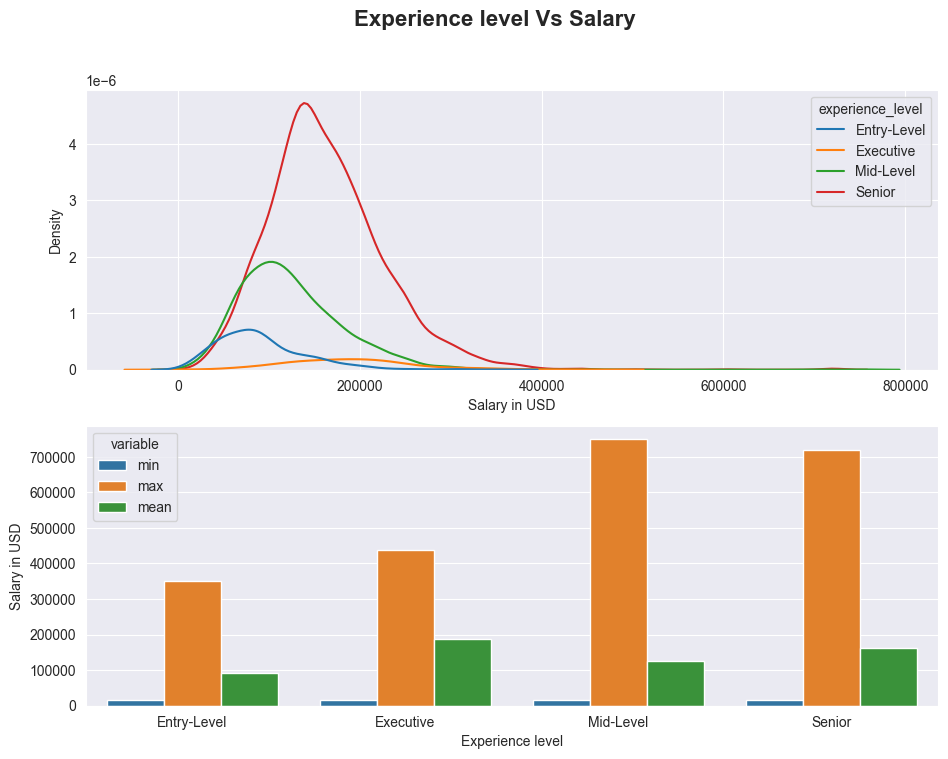

In [14]:
salary_experience = salary_data.groupby("experience_level")["salary_in_usd"]\
    .agg(["min","max","mean"])

salary_experience.reset_index(inplace=True)
print(salary_experience)

experience_agg = salary_experience.melt(value_vars=["min","max","mean"], id_vars="experience_level")
fig, ax = plt.subplots(nrows=2, figsize=(11,8))

experience_salary_plot = sns.kdeplot(data=salary_data,
                                     x="salary_in_usd",
                                     hue="experience_level",
                                     ax=ax[0])
fig.suptitle(
    "Experience level Vs Salary ",
    fontsize=16,
    fontweight='bold'
)
experience_salary_plot.set_xlabel(
    "Salary in USD"   
)

experience_salary_plot_2 = sns.barplot(
    data=experience_agg, x="experience_level",
    y="value",
    hue="variable",
    ax=ax[1]
)
experience_salary_plot_2.set_xlabel(
    "Experience level",
    )
experience_salary_plot_2.set_ylabel(
    "Salary in USD",
    )


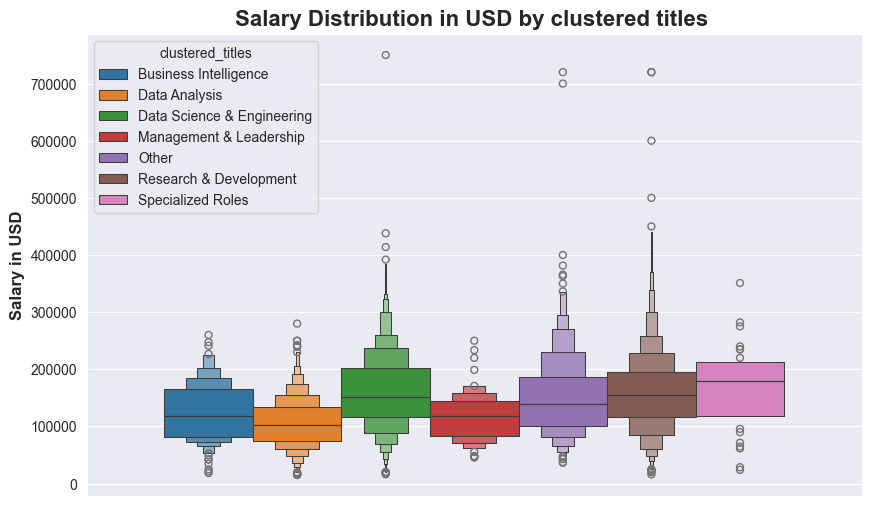

In [20]:
clustered_titles = salary_boxen_plot("clustered_titles")

C:\Users\nmn\AppData\Local\Temp\ipykernel_8412\2328178620.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clustered_titles = salary_data.groupby("clustered_titles")["salary_in_usd"]\


             clustered_titles    min     max           mean
0       Business Intelligence  18381  260000  125279.814655
1               Data Analysis  15000  280000  106593.949109
2  Data Science & Engineering  16228  750000  160931.525000
3     Management & Leadership  45600  250000  117971.320513
4                       Other  36483  720000  152101.550538
5      Research & Development  16000  720000  159532.882795
6           Specialized Roles  24000  351000  170347.928571


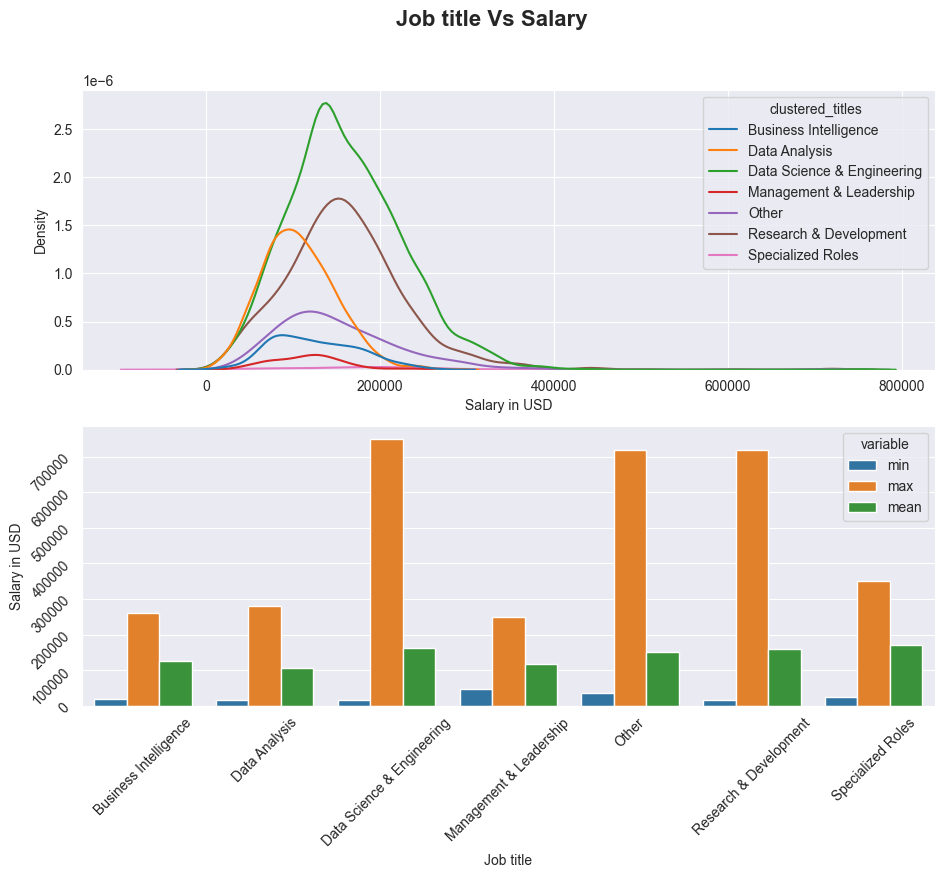

In [15]:
clustered_titles = salary_data.groupby("clustered_titles")["salary_in_usd"]\
    .agg(["min","max","mean"])

clustered_titles.reset_index(inplace=True)
print(clustered_titles)

clustered_titles_agg = clustered_titles.melt(value_vars=["min","max","mean"], id_vars="clustered_titles")
fig, ax = plt.subplots(nrows=2, figsize=(11,8))

clustered_titles_plot = sns.kdeplot(data=salary_data,
                                     x="salary_in_usd",
                                     hue="clustered_titles",
                                     ax=ax[0])
fig.suptitle(
    "Job title Vs Salary ",
    fontsize=16,
    fontweight='bold'
)
clustered_titles_plot.set_xlabel(
    "Salary in USD"   
)

clustered_titles_plot_2 = sns.barplot(
    data=clustered_titles_agg, x="clustered_titles",
    y="value",
    hue="variable",
    ax=ax[1]
)
clustered_titles_plot_2.set_xlabel(
    "Job title"
    )
clustered_titles_plot_2.set_ylabel(
    "Salary in USD",
    )
clustered_titles_plot_2.tick_params(rotation=45)

#### Outlier 

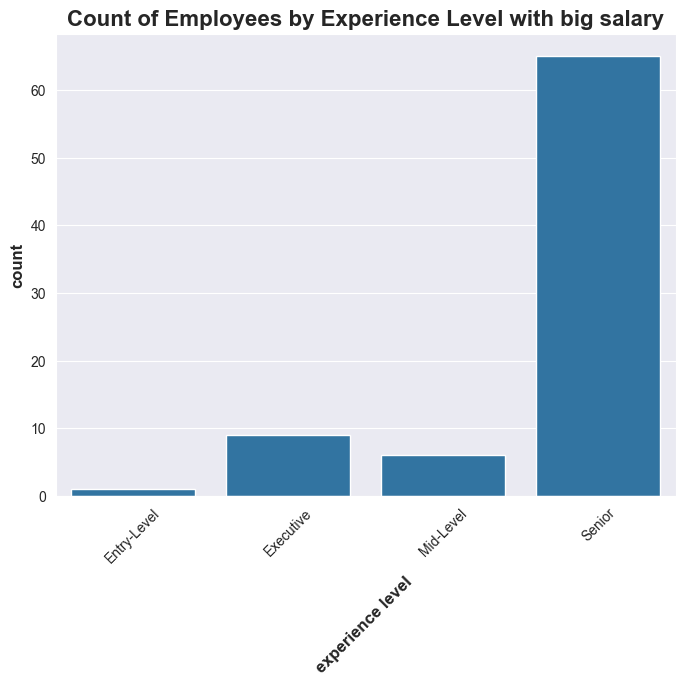

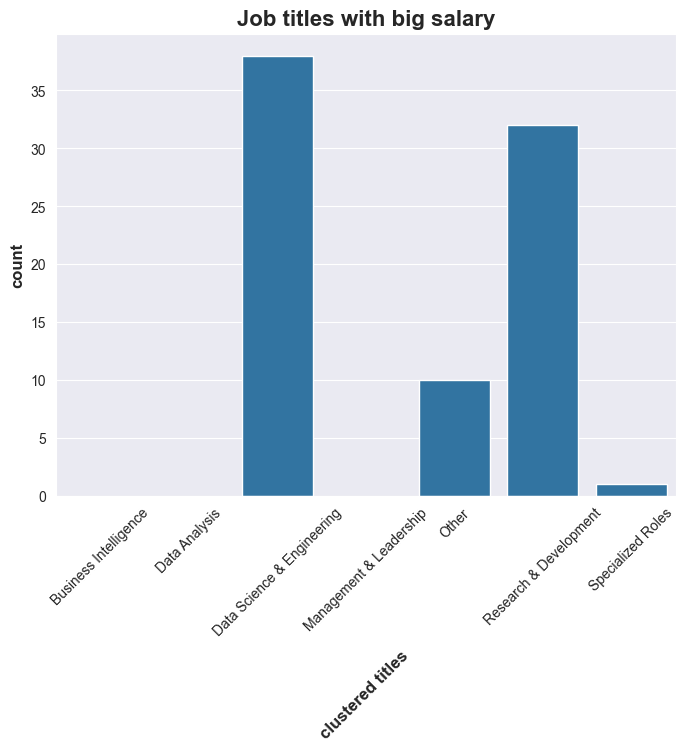

In [16]:
from scipy.stats import iqr
upper = salary_data["salary_in_usd"].quantile(.75) + (1.5* iqr(salary_data["salary_in_usd"]))

outlier_salary = salary_data[salary_data["salary_in_usd"]>upper]

out_exp = count_plot(outlier_salary["experience_level"],"Count of Employees by Experience Level with big salary")
out_tit = count_plot(outlier_salary["clustered_titles"],"Job titles with big salary")

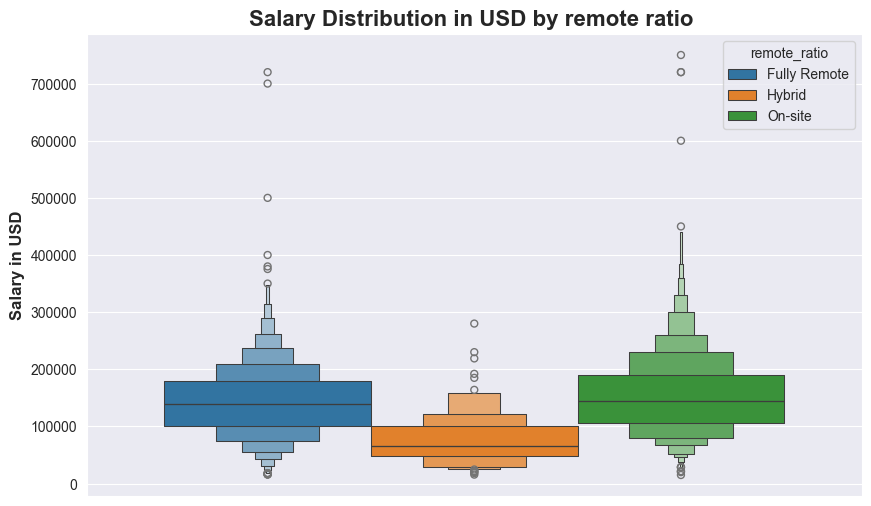

In [26]:
remote_ratios_distribution = salary_boxen_plot("remote_ratio")

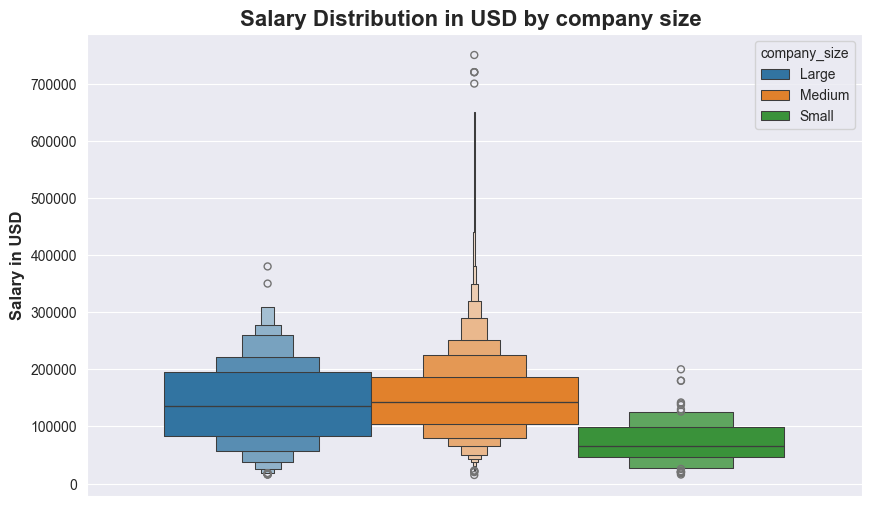

In [27]:
company_size_distributhon= salary_boxen_plot("company_size")

In [38]:
country = salary_data["company_location"].value_counts()
country = country[country > 10].index
company_location = salary_data[salary_data["company_location"].isin(country)]\
    .groupby("company_location")["salary_in_usd"]\
    .agg(["mean","max","min"]).sort_values(by="mean", ascending=False).head(n=10).reset_index()
    
print(company_location)

  company_location           mean       max      min
0    United States  156296.293957  750000.0  24000.0
1           Canada  145136.608696  329200.0  15000.0
2        Australia  131850.375000  300000.0  40000.0
3           France  103300.350000  240000.0  20000.0
4   United Kingdom   94872.856436  300000.0  26992.0
5          Germany   87778.647059  275000.0  25532.0
6      Netherlands   63068.454545  115573.0  25000.0
7            Spain   59839.576923  253750.0  21593.0
8         Portugal   49428.083333   95000.0  21593.0
9            India   36857.500000   82900.0  15809.0


C:\Users\nmn\AppData\Local\Temp\ipykernel_8412\2493714411.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("company_location")["salary_in_usd"]\
